In [1]:
%%time
# Loading of CoLoMoTo tools and Python modules used in this tutorial.
import numpy as np
import pandas as pd
import seaborn as sns
import ginsim
import biolqm
import maboss
import bns
import boolsim
from colomoto_jupyter import tabulate # for fixpoint table display
import matplotlib.pyplot as plt # for modifying plots
import os

This notebook has been executed using the docker image `colomoto/colomoto-docker:2025-03-01`

CPU times: user 2.5 s, sys: 1.06 s, total: 3.55 s
Wall time: 3.01 s


In [2]:
# Loading and visualisation of the model, pinned to the official source commit
# ce31e466f271918b8873f607cb90b3258603ec15

model_ginsim = ginsim.load(
    "https://raw.githubusercontent.com/colomoto/colomoto-tutorial-sizek/ce31e466f271918b8873f607cb90b3258603ec15/CellCycleControl_Sizek_PCB_2019.zginml"
)

ginsim.show(model_ginsim)

Downloading https://raw.githubusercontent.com/colomoto/colomoto-tutorial-sizek/ce31e466f271918b8873f607cb90b3258603ec15/CellCycleControl_Sizek_PCB_2019.zginml

Do not forget attaching "CellCycleControl_Sizek_PCB_2019.zginml" file with your notebook


/notebook/week7/CellCycleControl_Sizek_PCB_2019.zginml

In [3]:
# Conversion of the model for biolqm
model_biolqm = ginsim.to_biolqm(model_ginsim)

In [4]:
# By default, with bioLQM, nodes are set to zero at the initial state.
# Hence, we only need to declare the nodes active at the initial state.

init_active = {
    'AKT_B',
    'BCL2',
    'BCLXL',
    'Cdc20',
    'Cdc25A',
    'Cdc25B',
    'Cdc25C',
    'Cdh1',
    'CyclinA_mRNA',
    'CyclinD1',
    'E2F1',
    'ERK',
    'Emi1',
    'GF',
    'GF_High',
    'Grb2',
    'IAPs',
    'MCL_1',
    'MEK',
    'Myc',
    'ORC',
    'PDK1',
    'PI3K',
    'PIP3',
    'Plk1_H',
    'RAF',
    'RTK',
    'Ras',
    'S6K',
    'SOS',
    'TSC2',
    'UbcH10',
    'eIF4E',
    'f4N_DNA',
    'mTORC1',
    'mTORC2',
    'pAPC'
}

# dict-like representation, associating a node to either 0 or 1
init = {
    n: 1 if n in init_active else 0
    for n in map(str, model_biolqm.getComponents())
}

# str-like representation, for bioLQM
init_str = "".join(
    map(str, (init[n] for n in map(str, model_biolqm.getComponents())))
)

init_str

'111111111100000000100111000011101000011010010101011101000100011100000000100000000110110'

In [5]:
%%time
# Synchronous simulation.
# -i set of initial conditions specified for each node
# -m maximum number of steps after which the simulation stops
# -u updating type (synchronous by default)

trace = biolqm.trace(model_biolqm, f"-i {init_str} -m 50")
trace_df = pd.DataFrame([s for s in trace])
trace_df

CPU times: user 191 ms, sys: 104 ms, total: 295 ms
Wall time: 591 ms


,GF,RTK,Grb2,Ras,RAF,mTORC2,PI3K,PIP3,PDK1,AKT_B,p110_H,PI3K_H,AKT_H,FoxO3,PLCgamma,NeddL4,FoxO1,p21_mRNA,TSC2,PRAS40,Rheb,mTORC1,S6K,eIF4E,GSK3,p21,pRB,p27Kip1,Myc,CyclinD1,E2F1,CyclinE,ORC,Cdc6,Cdt1,Pre_RC,geminin,CyclinA_mRNA,Emi1,FoxM1,Cdc25A,CyclinA,Wee1,UbcH10,CyclinB,Cdc25B,Plk1,Cdc25C,Cdk1,pAPC,Cdc20,Cdh1,Replication,f4N_DNA,U_Kinetochores,Mad2,A_Kinetochores,Plk1_H,Ect2,Casp8,Casp2,MCL_1,BCLXL,BCL2,BAD,BIK,BIM,BID,BAK,BAX,Cyto_C,SMAC,IAPs,Casp9,Casp3,CAD,ATR,CHK1,Ca2,DAG,DR4_5,ERK,GF_High,IP3,MEK,SOS,Trail
0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,1,1,1,0,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,1,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
2,1,1,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
3,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,0,0,1,1,1,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,1,1,1,0,1,0,0,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
5,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1,1,1,0
6,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,1,1,0
7,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,1,1,0
8,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,0,1,1,1,0,1,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,1,1,1,1,1,0
9,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,1,1,1,1,1,0


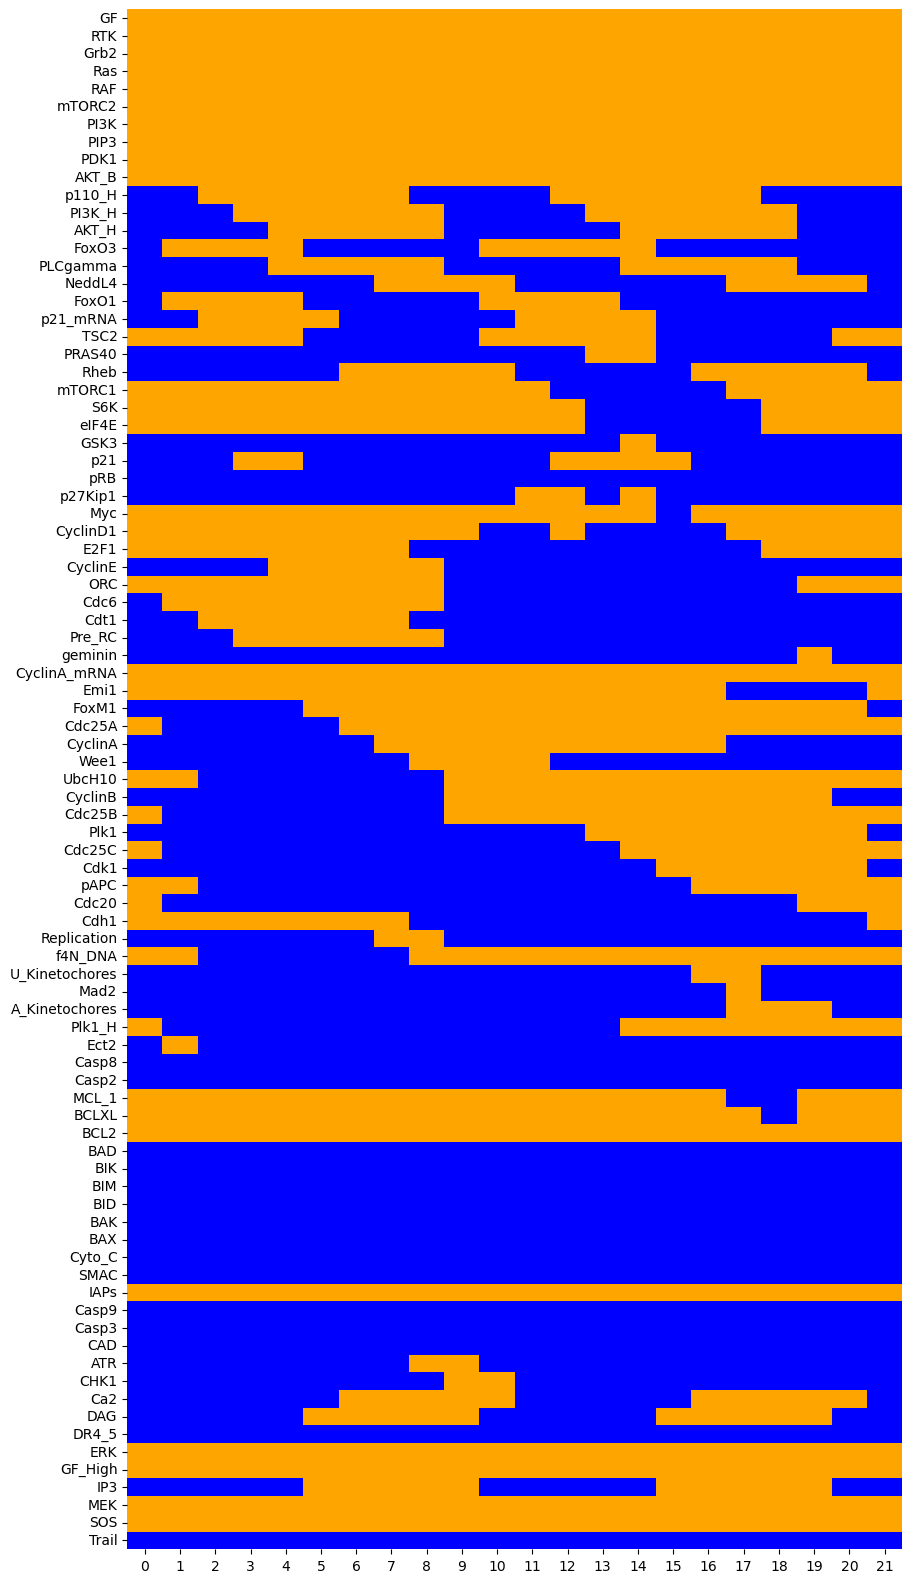

In [6]:
# Function used for plotting the dynamics of molecular species

def plotting(df):
    custom_cmap = sns.color_palette(['blue', 'orange'])
    fig = plt.figure(figsize=(10, 20))
    sns.heatmap(df.T, cmap=custom_cmap, annot=False, cbar=False)
    plt.show()

plotting(trace_df)

In [7]:
# Conversion of bioLQM model into the MaBoSS format

model_maboss = biolqm.to_maboss(model_biolqm)

In [8]:
# Delineation of MaBoSS simulation parameters

model_maboss.update_parameters(
    sample_count=5000,
    max_time=200,
    time_tick=0.5
)

In [9]:
# Define a wildtype model "WT" and select external variables

WT = model_maboss.copy()

# Select outputs for visualization of the results
WT.network.set_output(
    ('CyclinB', 'Casp3', 'PI3K_H', 'E2F1',
     'Replication', 'p21', 'RTK')
)

In [10]:
# Define a state corresponding to Sizek's initial condition

active_init = [k for (k, v) in init.items() if v == 1]

maboss.set_nodes_istate(WT, active_init, [0, 1])

In [11]:
%%time

# Run a MaBoSS simulation
run_WT = WT.run()

CPU times: user 0 ns, sys: 4.2 ms, total: 4.2 ms
Wall time: 25.2 s


Text(0.5, 1.0, 'WT entropy curves')

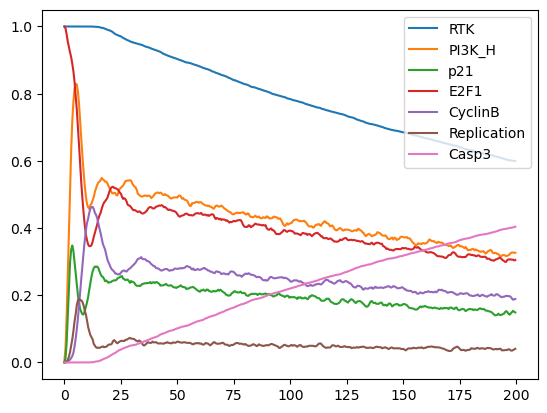

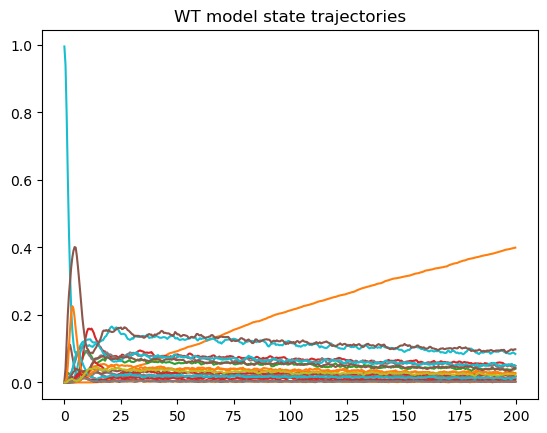

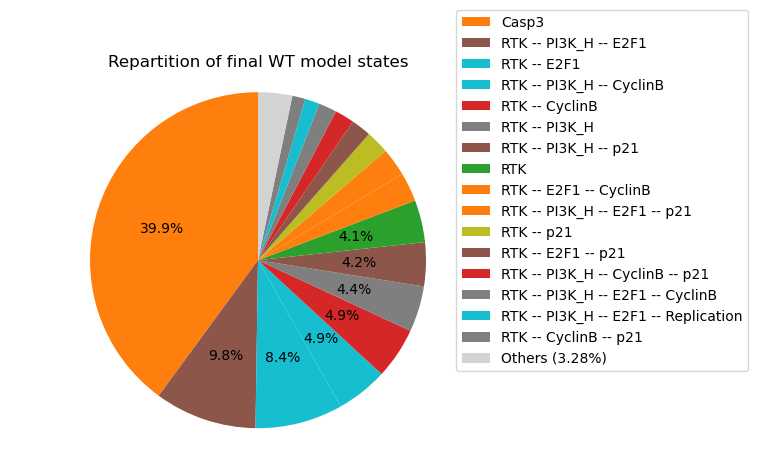

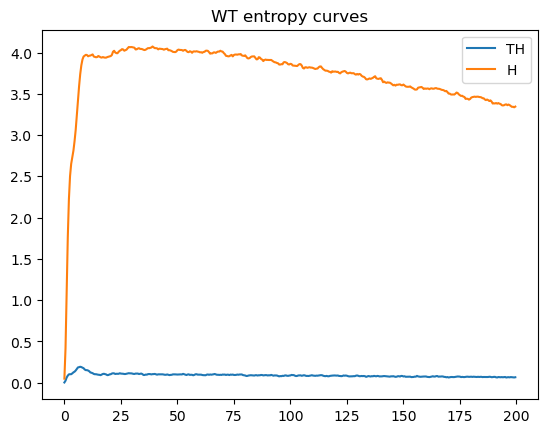

In [12]:
# Plot the trajectories of the WT simulation for selected nodes.
run_WT.get_nodes_probtraj().plot(legend=True)

# Plot the trajectories of the WT simulation with model states.
run_WT.plot_trajectory(legend=False)
plt.title('WT model state trajectories')

# Plot pie chart.
run_WT.plot_piechart()
plt.title('Repartition of final WT model states')

# Plot the state and transition entropy curves.
run_WT.plot_entropy_trajectory()
plt.title('WT entropy curves')

In [14]:
# Personal implementation - Casp8 ON
# Student number: 2024109784

mut = WT.copy()

# Force Casp8 to remain ON during the simulation
mut.mutate("Casp8", "ON")

# Run the perturbed simulation
mutres = mut.run()

print(type(run_WT))
print(type(mutres))

print("WT Casp3:")
print(run_WT.get_last_nodes_probtraj(as_series=True)["Casp3"])

print("Casp8 ON Casp3:")
print(mutres.get_last_nodes_probtraj(as_series=True)["Casp3"])

<class 'maboss.result.Result'>
<class 'maboss.result.Result'>
WT Casp3:
0.4038610000000001
Casp8 ON Casp3:
0.9995999999999999


In [15]:
wt_final = run_WT.get_last_nodes_probtraj(as_series=True)
mut_final = mutres.get_last_nodes_probtraj(as_series=True)

comparison = pd.DataFrame({
    "WT": wt_final,
    "Casp8_ON": mut_final
})

comparison["Change"] = comparison["Casp8_ON"] - comparison["WT"]
comparison["Absolute_change"] = comparison["Change"].abs()

comparison.sort_values("Absolute_change", ascending=False)

,WT,Casp8_ON,Change,Absolute_change
RTK,0.599258,0.0004,-0.598858,0.598858
Casp3,0.403861,0.9996,0.595739,0.595739
PI3K_H,0.326398,0.0002,-0.326198,0.326198
CyclinB,0.188777,0.0004,-0.188377,0.188377
E2F1,0.305074,NaN,NaN,NaN
Replication,0.040639,NaN,NaN,NaN
p21,0.148919,NaN,NaN,NaN


In [16]:
outputs = ['CyclinB', 'Casp3', 'PI3K_H', 'E2F1',
           'Replication', 'p21', 'RTK']

print("WT:")
print(run_WT.get_last_nodes_probtraj(as_series=True))

print("\nCasp8 ON:")
print(mutres.get_last_nodes_probtraj(as_series=True))

WT:
Casp3          0.403861
CyclinB        0.188777
E2F1           0.305074
PI3K_H         0.326398
RTK            0.599258
Replication    0.040639
p21            0.148919
Name: 199.5000, dtype: float64

Casp8 ON:
Casp3      0.9996
CyclinB    0.0004
PI3K_H     0.0002
RTK        0.0004
Name: 199.5000, dtype: float64


,WT,Assigned_variation
Casp3,0.403861,0.9996
CyclinB,0.188777,0.0004
E2F1,0.305074,NaN
PI3K_H,0.326398,0.0002
RTK,0.599258,0.0004
Replication,0.040639,NaN
p21,0.148919,NaN


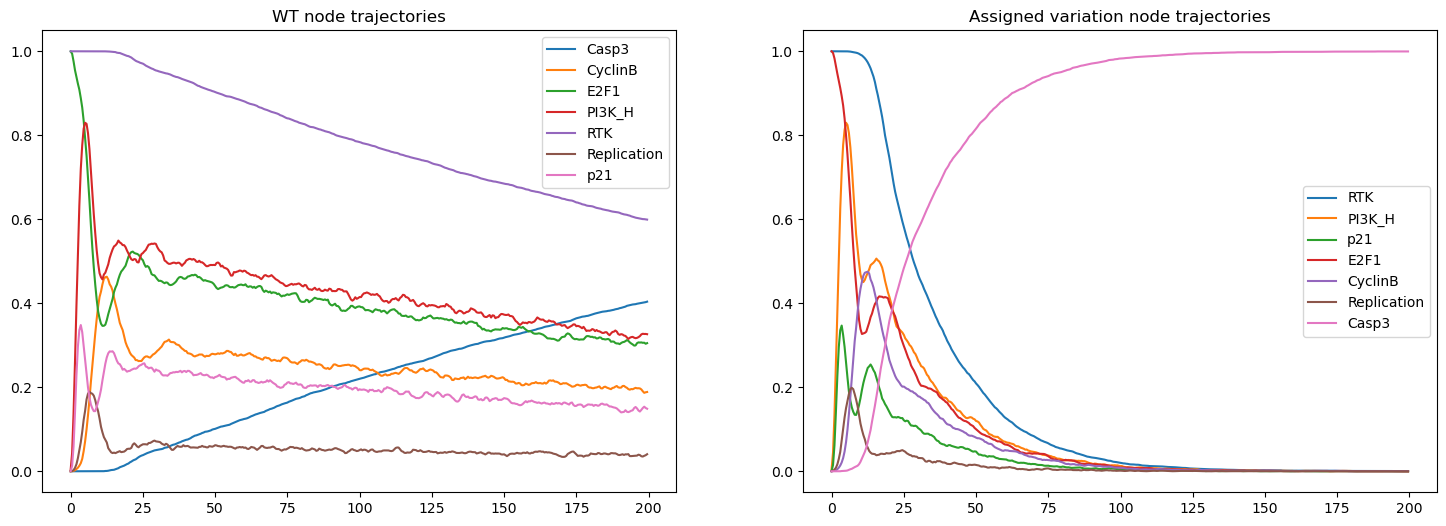

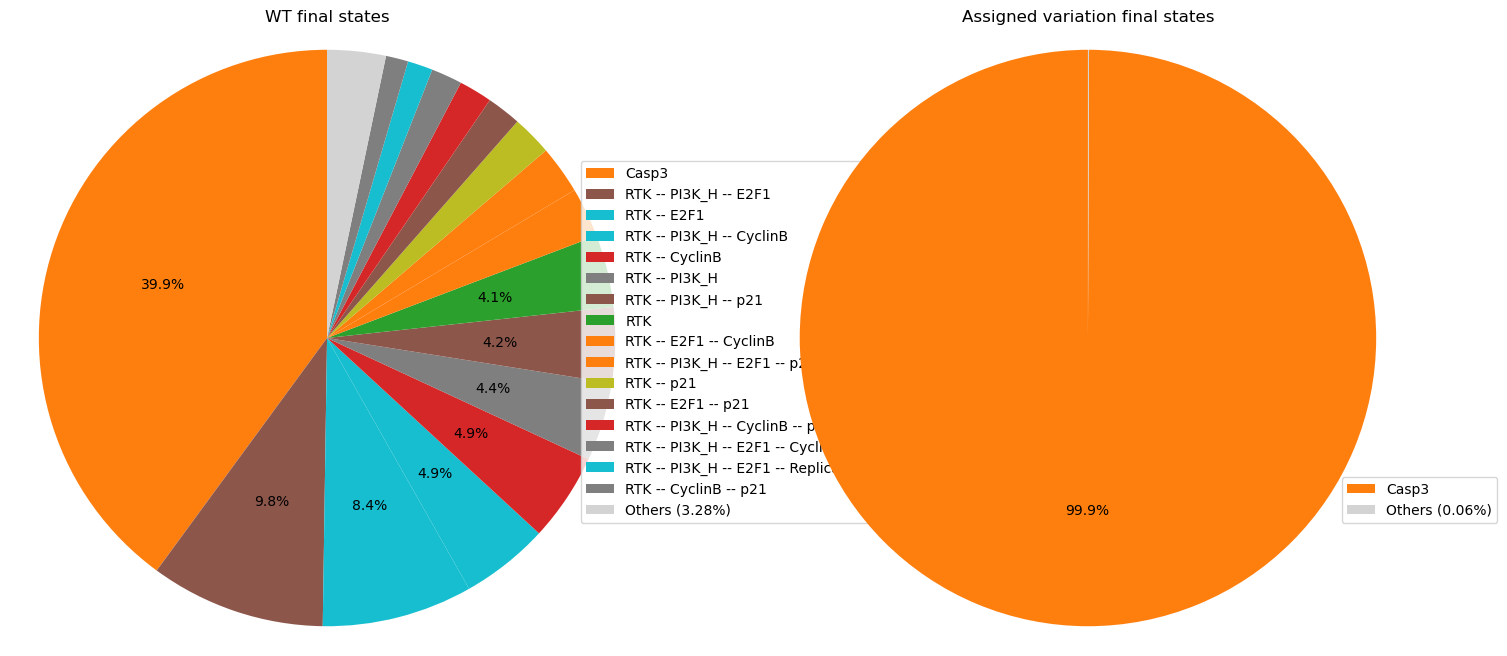

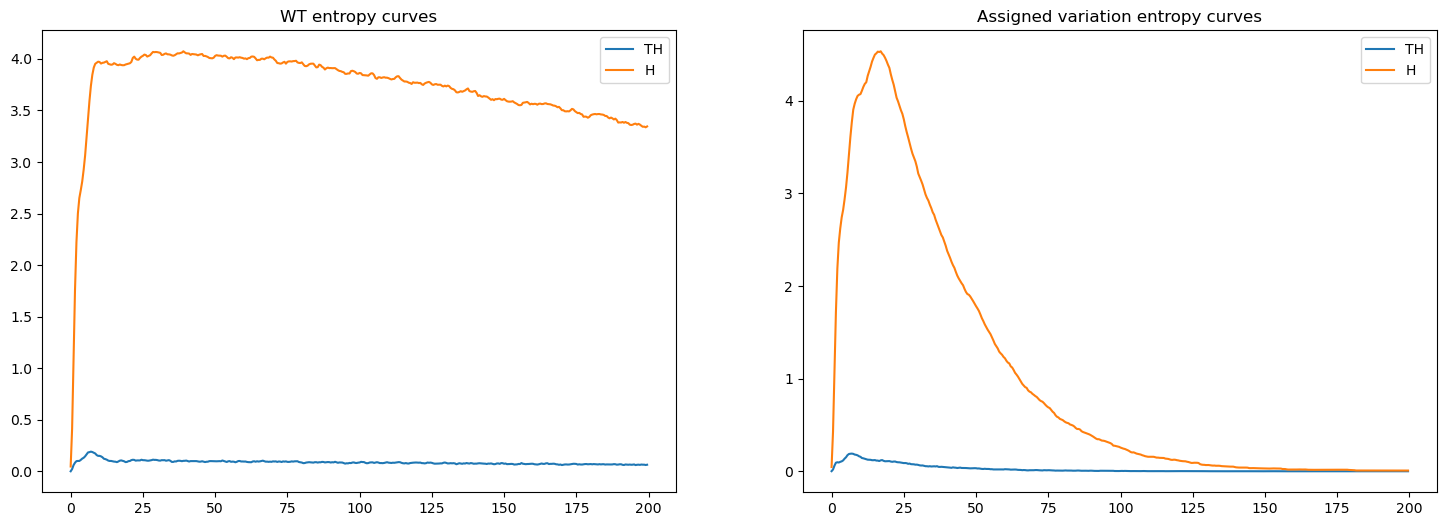

In [17]:
# Export the WT and assigned-variation results (figures + final probabilities).
import os
os.makedirs("results", exist_ok=True)

# 1) Node-probability trajectories, WT versus your variation.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
run_WT.get_nodes_probtraj().plot(ax=axes[0], legend=True)
axes[0].set_title("WT node trajectories")
mutres.get_nodes_probtraj().plot(ax=axes[1], legend=True)
axes[1].set_title("Assigned variation node trajectories")
fig.savefig("results/week7_node_trajectories.png", dpi=150, bbox_inches="tight")

# 2) Final-state pie charts.
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
run_WT.plot_piechart(axes=axes[0])
axes[0].set_title("WT final states")
mutres.plot_piechart(axes=axes[1])
axes[1].set_title("Assigned variation final states")
fig.savefig("results/week7_final_states.png", dpi=150, bbox_inches="tight")

# 3) Entropy trajectories.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
run_WT.plot_entropy_trajectory(axes=axes[0])
axes[0].set_title("WT entropy curves")
mutres.plot_entropy_trajectory(axes=axes[1])
axes[1].set_title("Assigned variation entropy curves")
fig.savefig("results/week7_entropy.png", dpi=150, bbox_inches="tight")

# 4) Final node probabilities as a CSV table.
final_probs = pd.DataFrame({
    "WT": run_WT.get_last_nodes_probtraj(as_series=True),
    "Assigned_variation": mutres.get_last_nodes_probtraj(as_series=True),
})

final_probs.to_csv("results/week7_final_node_probabilities.csv")
final_probs